In [13]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt

data = pd.read_csv('/fer2013.csv')

print("Shape of dataset:", data.shape)
data.head()

Shape of dataset: (35887, 3)


,emotion,pixels,Usage
0,0,70 80 82 72 58 58 60 63 54 58 60 48 89 115 121...,Training
1,0,151 150 147 155 148 133 111 140 170 174 182 15...,Training
2,2,231 212 156 164 174 138 161 173 182 200 106 38...,Training
3,4,24 32 36 30 32 23 19 20 30 41 21 22 32 34 21 1...,Training
4,6,4 0 0 0 0 0 0 0 0 0 0 0 3 15 23 28 48 50 58 84...,Training


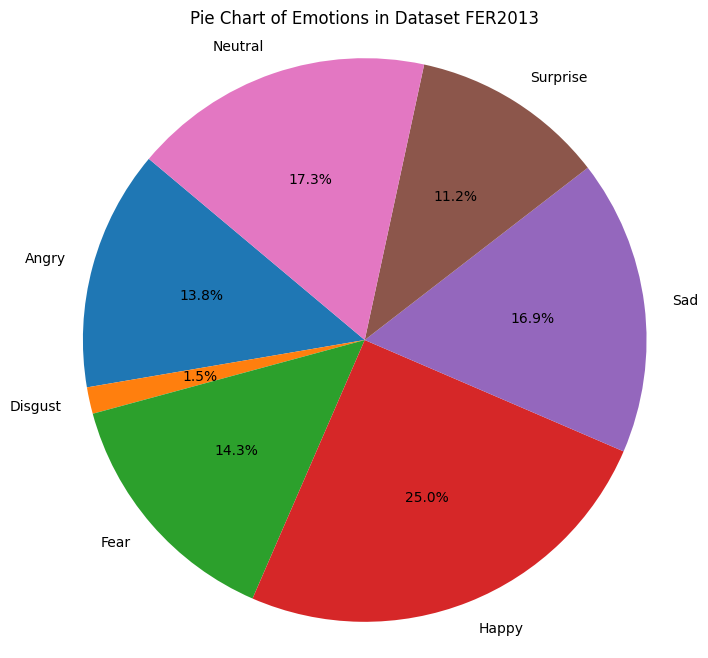

In [14]:
emotion_dict = {
    0: "Angry",
    1: "Disgust",
    2: "Fear",
    3: "Happy",
    4: "Sad",
    5: "Surprise",
    6: "Neutral"
}

emotion_types = [emotion_dict[i] for i in range(7)]
emotion_counts = data['emotion'].value_counts().sort_index()
counts = emotion_counts.values

# Then a Pie chart with labels and colors
plt.figure(figsize=(8, 8))
plt.pie(counts, labels=emotion_types, autopct='%1.1f%%', startangle=140)
plt.title("Pie Chart of Emotions in Dataset FER2013")
plt.axis('equal')  # Make the pie chart a circle
plt.show()

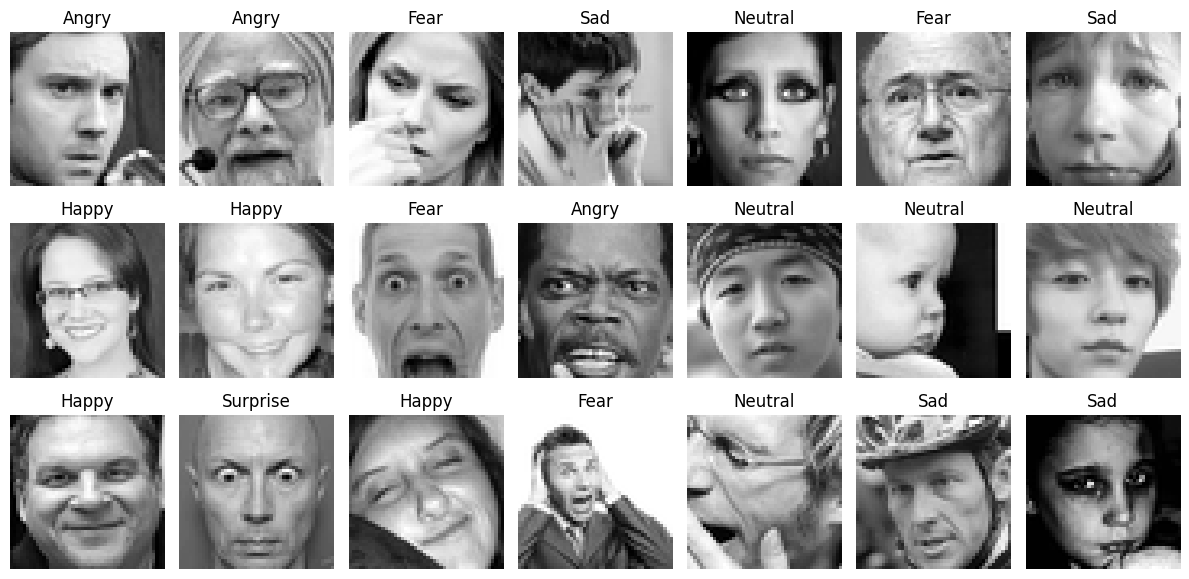

In [15]:
plt.figure(figsize=(12,6))
for emo in range(21):
    img_row = data.iloc[emo]
    img = np.fromstring(img_row['pixels'], sep=' ').reshape(48, 48)
    emotion_label = emotion_dict[img_row['emotion']]
    plt.subplot(3, 7, emo + 1) # 3 rows, 7 columns
    plt.imshow(img, cmap='gray')
    plt.title(emotion_label)
    plt.axis('off')
plt.tight_layout()
plt.show()

In [16]:
data.Usage.value_counts()

,count
Usage,
Training,28709
PublicTest,3589
PrivateTest,3589


In [17]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 48, 48, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 48, 48, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 12, 12, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     1,179,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,468,135 (5.60 MB)

 Trainable params: 1,468,135 (5.60 MB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 48, 48, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 48, 48, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 12, 12, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     1,179,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,468,135 (5.60 MB)

 Trainable params: 1,468,135 (5.60 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 509s 2s/step - accuracy: 0.2447 - loss: 1.8335 - val_accuracy: 0.2903 - val_loss: 1.7634
Epoch 2/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 558s 2s/step - accuracy: 0.3214 - loss: 1.7026 - val_accuracy: 0.4004 - val_loss: 1.5558
Epoch 3/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 497s 2s/step - accuracy: 0.4074 - loss: 1.5523 - val_accuracy: 0.4386 - val_loss: 1.4702
Epoch 4/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 498s 2s/step - accuracy: 0.4438 - loss: 1.4612 - val_accuracy: 0.4631 - val_loss: 1.4273
Epoch 5/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 508s 2s/step - accuracy: 0.4620 - loss: 1.4080 - val_accuracy: 0.4787 - val_loss: 1.3728
Epoch 6/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 561s 2s/step - accuracy: 0.4855 - loss: 1.3559 - val_accuracy: 0.5104 - val_loss: 1.3146
Epoch 7/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 501s 2s/step - accuracy: 0.5017 - loss: 1.3130 - val_accuracy: 0.5210 - val_loss: 1.2928
Epoch 8/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 505s 2s/step - accuracy: 0.5320 - loss: 1.2578 - val_accu

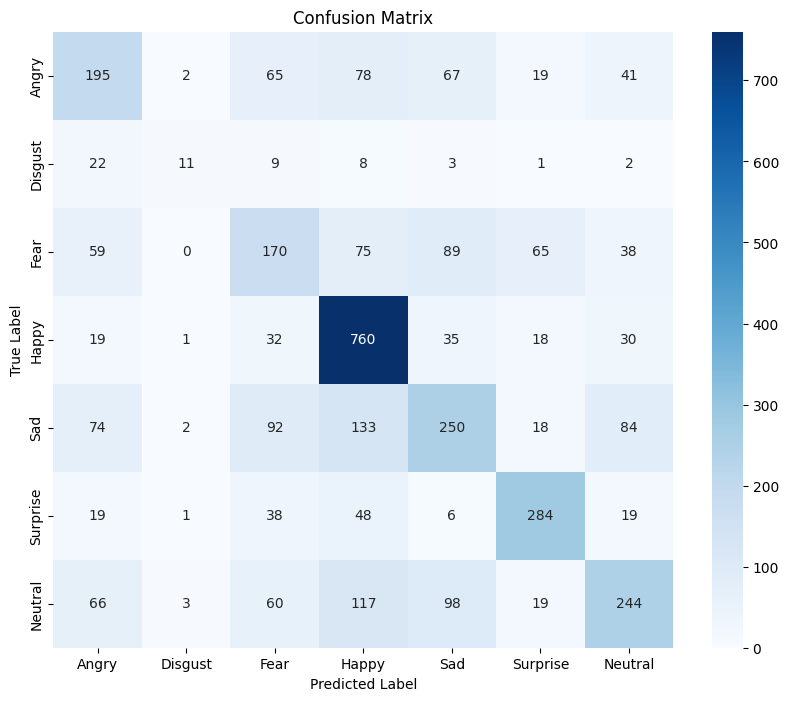

              precision    recall  f1-score   support

       Angry       0.43      0.42      0.42       467
     Disgust       0.55      0.20      0.29        56
        Fear       0.36      0.34      0.35       496
       Happy       0.62      0.85      0.72       895
         Sad       0.46      0.38      0.42       653
    Surprise       0.67      0.68      0.68       415
     Neutral       0.53      0.40      0.46       607

    accuracy                           0.53      3589
   macro avg       0.52      0.47      0.48      3589
weighted avg       0.52      0.53      0.52      3589



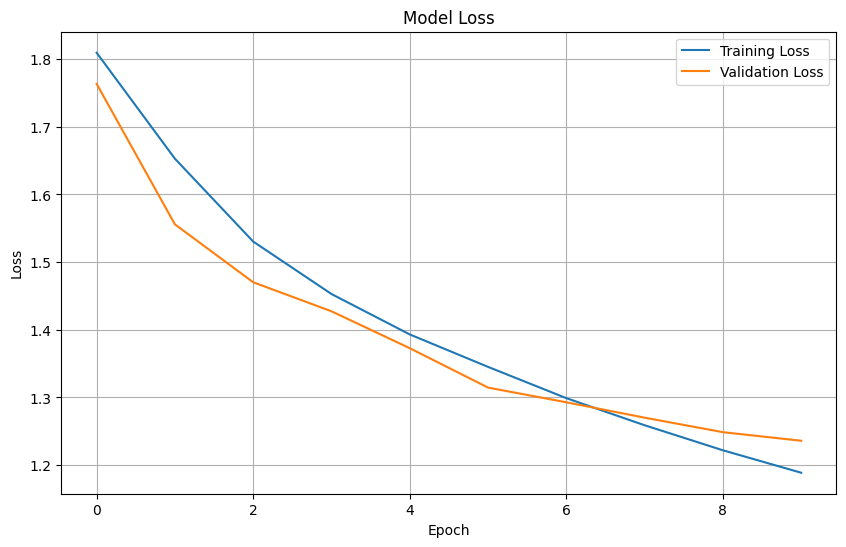

In [18]:
# Load FER-2013 dataset

data['pixels'] = data['pixels'].apply(lambda x: np.array(x.split(), dtype='float32'))

# Split the data into training and testing sets
train_data = data[data['Usage'] == 'Training']
test_data = data[data['Usage'] == 'PublicTest']

# Extract pixels and labels
x_train = np.array(train_data['pixels'].tolist()).reshape(-1, 48, 48, 1)
y_train = np.array(train_data['emotion'])
x_test = np.array(test_data['pixels'].tolist()).reshape(-1, 48, 48, 1)
y_test = np.array(test_data['emotion'])

# Normalize the pixel values
x_train /= 255.0
x_test /= 255.0

# Convert labels to categorical format
num_classes = len(np.unique(y_train))
y_train = to_categorical(y_train, num_classes)
y_test = to_categorical(y_test, num_classes)

# # Build the CNN model
# model = Sequential([
#     Conv2D(32, (3, 3), activation='relu', input_shape=(48, 48, 1)),
#     MaxPooling2D((2, 2)),
#     Dropout(0.25),
#     Conv2D(64, (3, 3), activation='relu'),
#     MaxPooling2D((2, 2)),
#     Dropout(0.25),
#     Conv2D(128, (3, 3), activation='relu'),
#     MaxPooling2D((2, 2)),
#     Dropout(0.25),
#     Flatten(),
#     Dense(512, activation='relu'),
#     Dropout(0.5),
#     Dense(num_classes, activation='softmax')
# ])


# FER2013 has 48x48 grayscale images and 7 emotion classes
model = Sequential()

# First Conv block (2 Conv + MaxPooling)
model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(48, 48, 1), padding='same'))
model.add(Conv2D(32, (3, 3), activation='relu', padding='same'))
model.add(MaxPooling2D(pool_size=(2, 2)))

# Second Conv block
model.add(Conv2D(64, (3, 3), activation='relu', padding='same'))
model.add(Conv2D(64, (3, 3), activation='relu', padding='same'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.2))

# Third Conv block
model.add(Conv2D(128, (3, 3), activation='relu', padding='same'))
model.add(Conv2D(128, (3, 3), activation='relu', padding='same'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.2))

# Fully connected layers
model.add(Flatten())
model.add(Dense(256, activation='relu'))
model.add(Dense(7, activation='softmax'))  # 7 emotion classes

# Summary
model.summary()


model.compile(loss='categorical_crossentropy', optimizer=Adam(0.0001), metrics=['accuracy'])
model.summary()

# Train the model
history = model.fit(x_train, y_train, validation_data=(x_test, y_test), batch_size=128, epochs=10)

# Evaluate the model
results = model.evaluate(x_test, y_test)
print(f"Test Loss: {results[0]}, Test Accuracy: {results[1]}")

# Predict the labels for the test set
y_pred = model.predict(x_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

# Generate the confusion matrix
cm = confusion_matrix(y_true, y_pred_classes)
class_names = ['Angry', 'Disgust', 'Fear', 'Happy', 'Sad', 'Surprise', 'Neutral']

# Plot the confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

# Print classification report
print(classification_report(y_true, y_pred_classes, target_names=class_names))

# Plot training & validation loss values
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.grid(True)
plt.show()

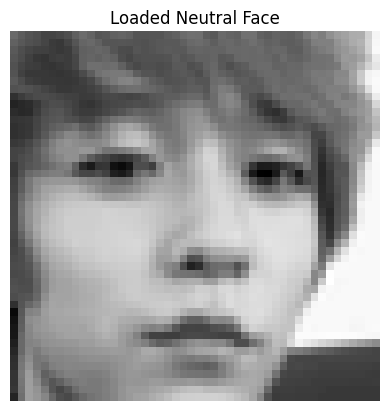

In [26]:
from PIL import Image
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

# === Load the image ===
img_path = '/Screenshot 2025-06-25 100950.png'  # replace with your filename
img = Image.open(img_path).convert('L')  # convert to grayscale

# Resize to 48x48 if needed
img = img.resize((48, 48))

# Convert to numpy and normalize
neutral_img = np.array(img).astype(np.float32) / 255.0  # shape: (48, 48)

# Expand dimensions: (1, 48, 48, 1)
input_array = np.expand_dims(neutral_img, axis=(0, -1))
input_tensor = tf.Variable(input_array)

# Sanity check
plt.imshow(neutral_img, cmap='gray')
plt.title("Loaded Neutral Face")
plt.axis('off')
plt.show()


In [20]:
target_class = 3  # Replace with your index for 'happy'
optimizer = tf.keras.optimizers.Adam(learning_rate=0.05)

for step in range(100):
    with tf.GradientTape() as tape:
        tape.watch(input_tensor)
        preds = model(input_tensor, training=False)
        loss = -preds[0, target_class]

    grads = tape.gradient(loss, input_tensor)
    grads /= (tf.math.reduce_std(grads) + 1e-8)

    optimizer.apply_gradients([(grads, input_tensor)])
    input_tensor.assign(tf.clip_by_value(input_tensor, 0.0, 1.0))

    if step % 10 == 0:
        print(f"Step {step}, Class {target_class} Confidence: {-loss.numpy():.4f}")


Step 0, Class 3 Confidence: 0.0093
Step 10, Class 3 Confidence: 1.0000
Step 20, Class 3 Confidence: 1.0000
Step 30, Class 3 Confidence: 1.0000
Step 40, Class 3 Confidence: 1.0000
Step 50, Class 3 Confidence: 1.0000
Step 60, Class 3 Confidence: 1.0000
Step 70, Class 3 Confidence: 1.0000
Step 80, Class 3 Confidence: 1.0000
Step 90, Class 3 Confidence: 1.0000


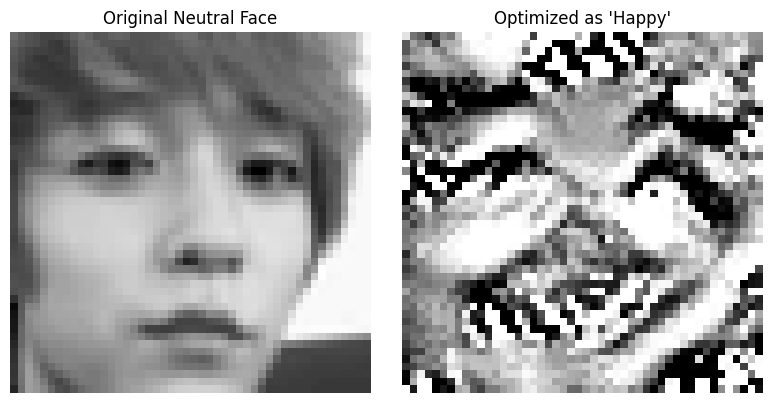

In [21]:
# Resulting image
result = input_tensor.numpy().squeeze()

# Plot
plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.imshow(neutral_img, cmap='gray')
plt.title("Original Neutral Face")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(result, cmap='gray')
plt.title("Optimized as 'Happy'")
plt.axis('off')
plt.tight_layout()
plt.show()


In [23]:
# === Predict using the "happy-ified" result image ===
# Prepare result image for model input
result_input = np.expand_dims(result, axis=(0, -1)).astype(np.float32)  # shape: (1, 48, 48, 1)

# Run prediction
final_preds = model.predict(result_input)

# Interpret prediction
emotion_classes = ['Angry', 'Disgust', 'Fear', 'Happy', 'Sad', 'Surprise', 'Neutral']
predicted_class = np.argmax(final_preds[0])
confidence = final_preds[0][predicted_class]

print(f"\nPredicted Emotion: {emotion_classes[predicted_class]} ({confidence:.2%} confidence)")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step

Predicted Emotion: Happy (100.00% confidence)


In [24]:
# === Predict using the "happy-ified" result image ===
result_input = np.expand_dims(result, axis=(0, -1)).astype(np.float32)  # shape: (1, 48, 48, 1)

# Run prediction
final_preds = model.predict(result_input)

# Emotion class labels (update if your model uses a different order)
emotion_classes = ['Angry', 'Disgust', 'Fear', 'Happy', 'Sad', 'Surprise', 'Neutral']

# Print all class probabilities
print("Class Probabilities:")
for i, prob in enumerate(final_preds[0]):
    print(f"{emotion_classes[i]:<10}: {prob:.4f}")

# Print the top predicted class
predicted_class = np.argmax(final_preds[0])
confidence = final_preds[0][predicted_class]
print(f"\nPredicted Emotion: {emotion_classes[predicted_class]} ({confidence:.2%} confidence)")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
Class Probabilities:
Angry     : 0.0000
Disgust   : 0.0000
Fear      : 0.0000
Happy     : 1.0000
Sad       : 0.0000
Surprise  : 0.0000
Neutral   : 0.0000

Predicted Emotion: Happy (100.00% confidence)
